In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

# Load master
master = pd.read_csv('data/olist_master.csv', parse_dates=['order_purchase_timestamp'])

print(f"Master table loaded ✓  |  {master.shape[0]:,} rows  |  {master.shape[1]} columns")

Master table loaded ✓  |  113,425 rows  |  38 columns


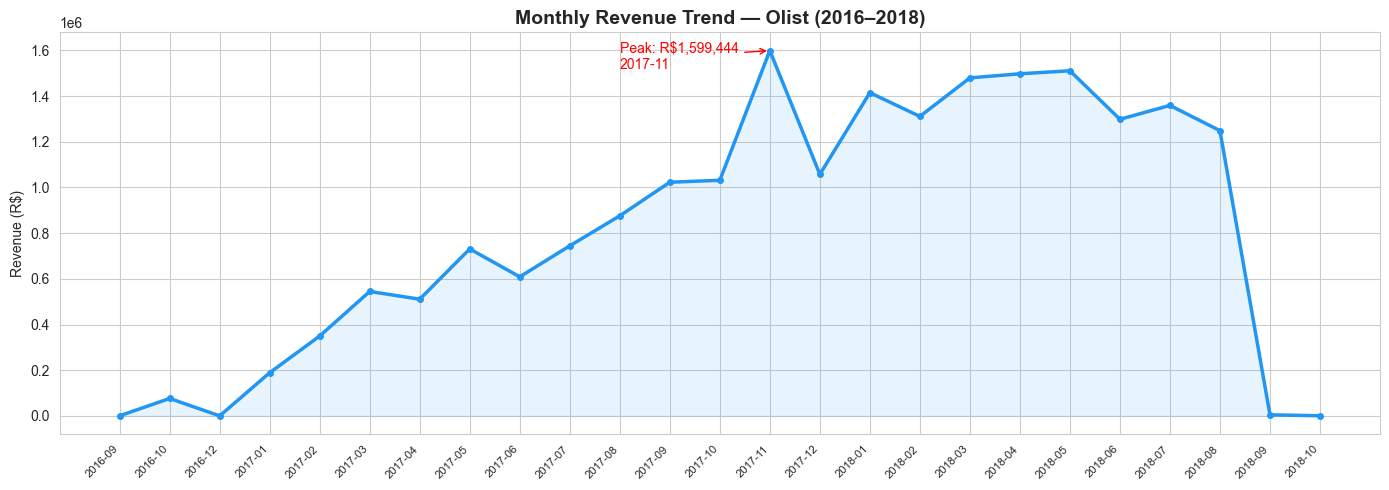


Peak month  : 2017-11
Peak revenue: R$ 1,599,444.18


In [2]:
# Finding 1: Monthly revenue trend
monthly_revenue = (
    master.dropna(subset=['payment_value'])
    .groupby(master['order_purchase_timestamp'].dt.to_period('M'))
    ['payment_value'].sum()
    .reset_index()
)
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'],
         color='#2196F3', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'],
                 alpha=0.1, color='#2196F3')

# Highlight the peak
peak_idx = monthly_revenue['revenue'].idxmax()
peak_month = monthly_revenue.loc[peak_idx, 'month']
peak_val = monthly_revenue.loc[peak_idx, 'revenue']
plt.annotate(f'Peak: R${peak_val:,.0f}\n{peak_month}',
             xy=(peak_idx, peak_val),
             xytext=(peak_idx - 3, peak_val * 0.95),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.xticks(range(len(monthly_revenue)), monthly_revenue['month'],
           rotation=45, ha='right', fontsize=8)
plt.title('Monthly Revenue Trend — Olist (2016–2018)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (R$)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('finding1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPeak month  : {peak_month}")
print(f"Peak revenue: R$ {peak_val:,.2f}")

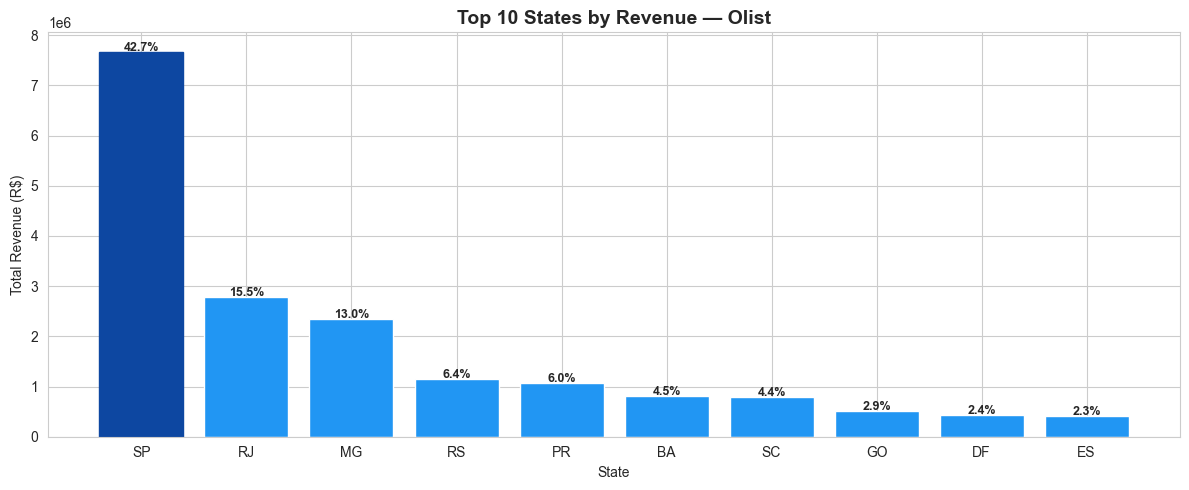

state    revenue       pct
   SP 7673188.55 42.665324
   RJ 2783724.26 15.478376
   MG 2341861.47 13.021481
   RS 1152019.17  6.405586
   PR 1074614.19  5.975190
   BA  802416.72  4.461687
   SC  799135.92  4.443445
   GO  516182.51  2.870136
   DF  434512.55  2.416025
   ES  406946.26  2.262748


In [3]:
# Finding 2: Revenue by state
state_revenue = (
    master.dropna(subset=['payment_value', 'customer_state'])
    .groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
state_revenue.columns = ['state', 'revenue']
state_revenue['pct'] = state_revenue['revenue'] / state_revenue['revenue'].sum() * 100

plt.figure(figsize=(12, 5))
bars = plt.bar(state_revenue['state'], state_revenue['revenue'],
               color='#2196F3', edgecolor='white')

# Highlight top state
bars[0].set_color('#0D47A1')

for bar, pct in zip(bars, state_revenue['pct']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20000,
             f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.title('Top 10 States by Revenue — Olist', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue (R$)')
plt.xlabel('State')
plt.tight_layout()
plt.savefig('finding2_revenue_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print(state_revenue[['state', 'revenue', 'pct']].to_string(index=False))

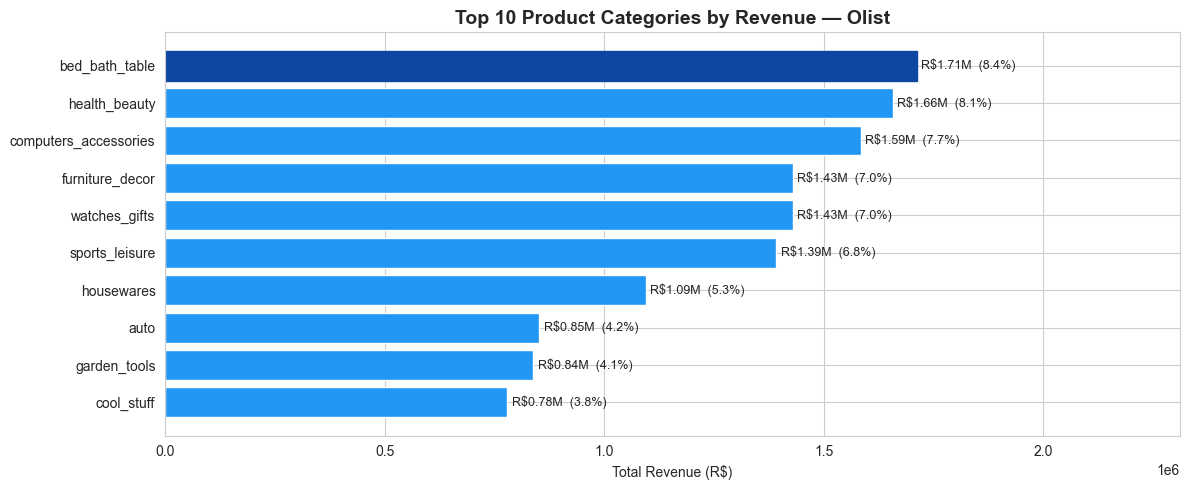

             category    revenue      pct
       bed_bath_table 1712553.67 8.365867
        health_beauty 1657373.12 8.096308
computers_accessories 1585330.45 7.744378
      furniture_decor 1430176.39 6.986447
        watches_gifts 1429216.68 6.981758
       sports_leisure 1392127.56 6.800577
           housewares 1094758.13 5.347920
                 auto  852294.33 4.163479
         garden_tools  838280.75 4.095022
           cool_stuff  779698.00 3.808844


In [4]:
# Finding 3: Top categories by revenue
category_revenue = (
    master.dropna(subset=['payment_value', 'category_en'])
    .groupby('category_en')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
category_revenue.columns = ['category', 'revenue']
category_revenue['pct'] = (
    category_revenue['revenue'] / master['payment_value'].sum() * 100
)

plt.figure(figsize=(12, 5))
bars = plt.barh(category_revenue['category'][::-1],
                category_revenue['revenue'][::-1],
                color='#2196F3', edgecolor='white')
bars[-1].set_color('#0D47A1')

for bar, pct in zip(bars[::-1], category_revenue['pct']):
    plt.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'R${bar.get_width()/1e6:.2f}M  ({pct:.1f}%)',
             va='center', fontsize=9)

plt.title('Top 10 Product Categories by Revenue — Olist', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.xlim(0, category_revenue['revenue'].max() * 1.35)
plt.tight_layout()
plt.savefig('finding3_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print(category_revenue[['category','revenue','pct']].to_string(index=False))

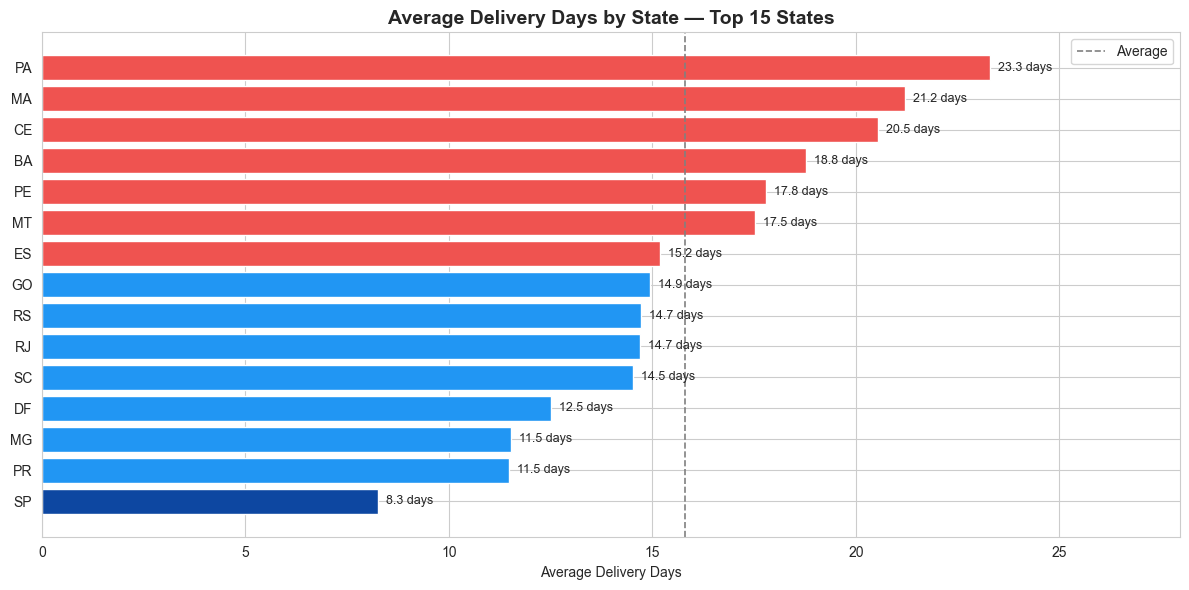

customer_state  avg_delivery  order_count
            SP      8.259663        40494
            PR     11.480793         4923
            MG     11.514091        11354
            DF     12.501486         2080
            SC     14.517208         3546
            RJ     14.688821        12350
            RS     14.708299         5344
            GO     14.948177         1957
            ES     15.192809         1995
            MT     17.508197          886
            PE     17.792096         1593
            BA     18.774640         3256
            CE     20.537167         1279
            MA     21.203750          717
            PA     23.301708          946


In [5]:
# Finding 4: Average delivery days by state (top 15 by order volume)
delivery_by_state = (
    master[master['was_delivered'] == True]
    .dropna(subset=['delivery_days', 'customer_state'])
    .groupby('customer_state')
    .agg(
        avg_delivery = ('delivery_days', 'mean'),
        order_count  = ('order_id',      'nunique')
    )
    .reset_index()
    .sort_values('order_count', ascending=False)
    .head(15)
    .sort_values('avg_delivery', ascending=True)
)

colors = ['#0D47A1' if d <= 10 else '#2196F3' if d <= 15 else '#EF5350'
          for d in delivery_by_state['avg_delivery']]

plt.figure(figsize=(12, 6))
bars = plt.barh(delivery_by_state['customer_state'],
                delivery_by_state['avg_delivery'],
                color=colors, edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f} days', va='center', fontsize=9)

plt.axvline(x=delivery_by_state['avg_delivery'].mean(),
            color='gray', linestyle='--', linewidth=1.2, label='Average')
plt.title('Average Delivery Days by State — Top 15 States', fontsize=14, fontweight='bold')
plt.xlabel('Average Delivery Days')
plt.xlim(0, delivery_by_state['avg_delivery'].max() * 1.2)
plt.legend()
plt.tight_layout()
plt.savefig('finding4_delivery_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print(delivery_by_state[['customer_state','avg_delivery','order_count']].to_string(index=False))

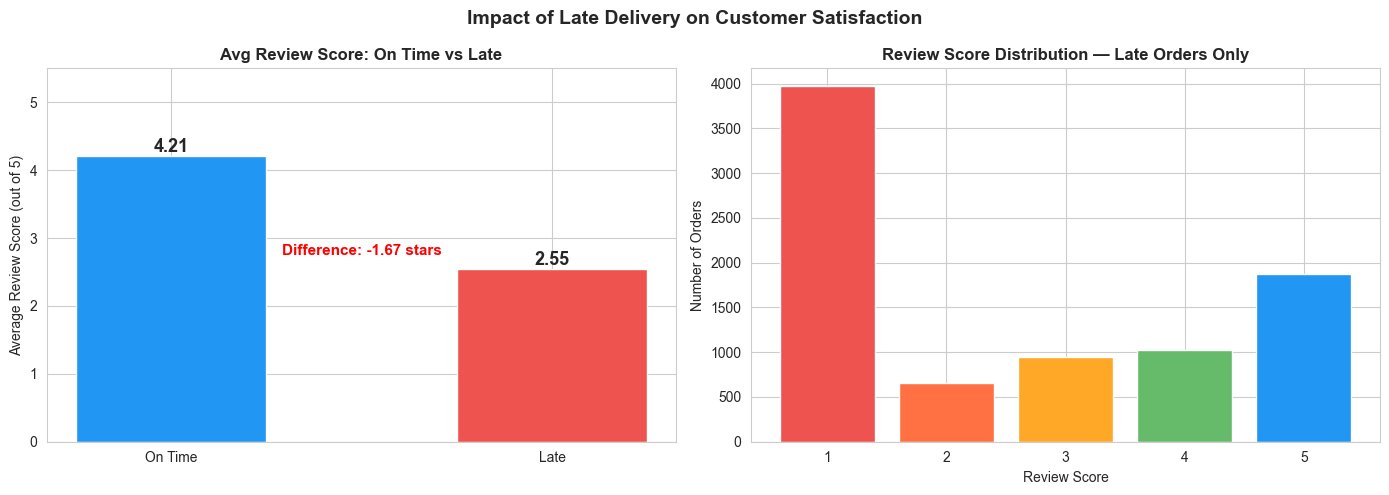

On-time avg score : 4.21
Late avg score    : 2.55
Score drop        : -1.67 stars


In [6]:
# Finding 5: Late deliveries vs review scores
late_vs_score = (
    master[master['was_delivered'] == True]
    .dropna(subset=['was_late', 'review_score'])
    .groupby('was_late')['review_score']
    .agg(['mean', 'count'])
    .reset_index()
)
late_vs_score.columns = ['was_late', 'avg_score', 'count']
late_vs_score['label'] = late_vs_score['was_late'].map(
    {False: 'On Time', True: 'Late'}
)

on_time_score = late_vs_score[late_vs_score['was_late'] == False]['avg_score'].values[0]
late_score    = late_vs_score[late_vs_score['was_late'] == True]['avg_score'].values[0]
diff          = on_time_score - late_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: avg review score comparison
colors = ['#2196F3', '#EF5350']
bars = axes[0].bar(late_vs_score['label'], late_vs_score['avg_score'],
                   color=colors, width=0.5, edgecolor='white')
for bar, score in zip(bars, late_vs_score['avg_score']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{score:.2f}', ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 5.5)
axes[0].set_title('Avg Review Score: On Time vs Late', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Review Score (out of 5)')
axes[0].annotate(f'Difference: -{diff:.2f} stars',
                 xy=(0.5, 0.5), xycoords='axes fraction',
                 ha='center', fontsize=11, color='red',
                 fontweight='bold')

# Right: review score distribution for late orders
late_orders = master[(master['was_delivered'] == True) &
                     (master['was_late'] == True)]
score_dist = late_orders['review_score'].value_counts().sort_index()
axes[1].bar(score_dist.index, score_dist.values,
            color=['#EF5350','#FF7043','#FFA726','#66BB6A','#2196F3'],
            edgecolor='white')
axes[1].set_title('Review Score Distribution — Late Orders Only', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Impact of Late Delivery on Customer Satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('finding5_late_vs_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"On-time avg score : {on_time_score:.2f}")
print(f"Late avg score    : {late_score:.2f}")
print(f"Score drop        : -{diff:.2f} stars")

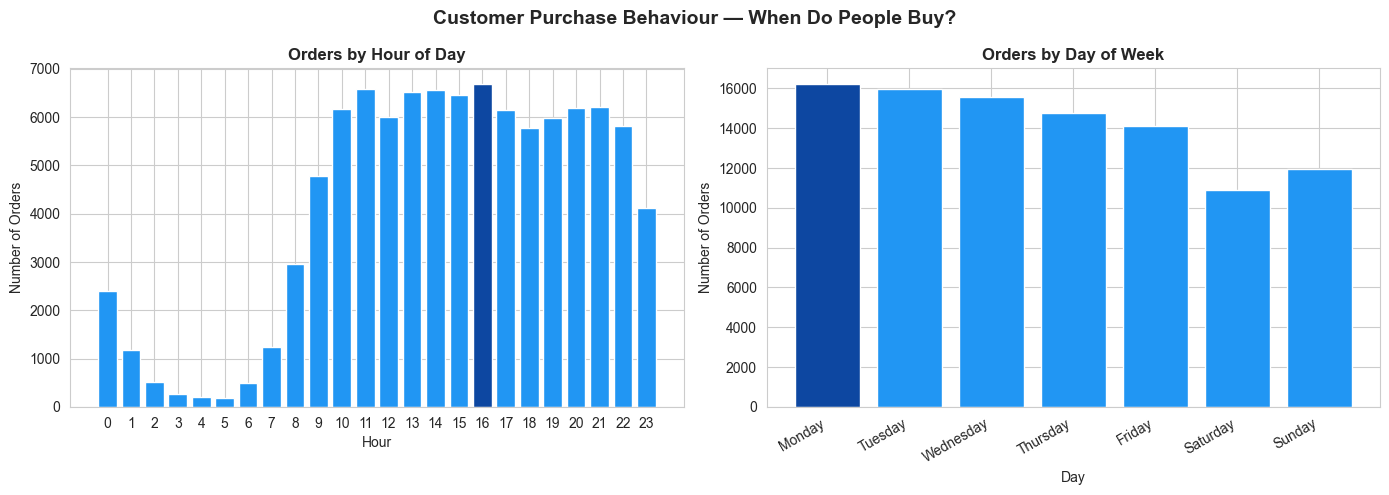

Peak hour : 16:00
Peak day  : Monday

Orders by day:
      day  orders
   Monday   16196
  Tuesday   15963
Wednesday   15552
 Thursday   14761
   Friday   14122
 Saturday   10887
   Sunday   11960


In [7]:
# Finding 6: Purchase behaviour by hour and day
master['hour'] = master['order_purchase_timestamp'].dt.hour
master['day_of_week'] = master['order_purchase_timestamp'].dt.day_name()

# Orders by hour
hourly = master.groupby('hour')['order_id'].nunique().reset_index()
hourly.columns = ['hour', 'orders']

# Orders by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = (master.groupby('day_of_week')['order_id']
         .nunique()
         .reindex(day_order)
         .reset_index())
daily.columns = ['day', 'orders']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly
peak_hour = hourly.loc[hourly['orders'].idxmax(), 'hour']
colors_h = ['#0D47A1' if h == peak_hour else '#2196F3' for h in hourly['hour']]
axes[0].bar(hourly['hour'], hourly['orders'], color=colors_h, edgecolor='white')
axes[0].set_title('Orders by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xticks(range(0, 24))

# Daily
peak_day = daily.loc[daily['orders'].idxmax(), 'day']
colors_d = ['#0D47A1' if d == peak_day else '#2196F3' for d in daily['day']]
axes[1].bar(daily['day'], daily['orders'], color=colors_d, edgecolor='white')
axes[1].set_title('Orders by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Orders')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Customer Purchase Behaviour — When Do People Buy?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('finding6_purchase_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak hour : {peak_hour}:00")
print(f"Peak day  : {peak_day}")
print(f"\nOrders by day:\n{daily.to_string(index=False)}")

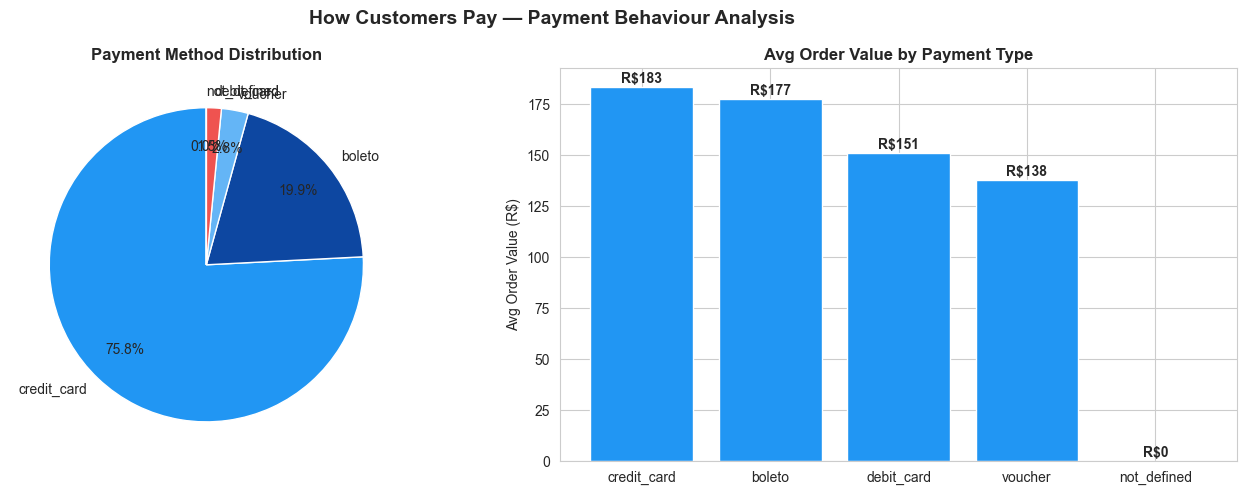

payment_type  orders       pct
 credit_card   75387 75.811545
      boleto   19784 19.895414
     voucher    2739  2.754425
  debit_card    1527  1.535599
 not_defined       3  0.003017

Avg credit card installments: 3.7


In [8]:
# Finding 7: Payment methods
payment_dist = (
    master.dropna(subset=['payment_type'])
    .groupby('payment_type')['order_id']
    .nunique()
    .reset_index()
    .sort_values('order_id', ascending=False)
)
payment_dist.columns = ['payment_type', 'orders']
payment_dist['pct'] = payment_dist['orders'] / payment_dist['orders'].sum() * 100

# Avg installments for credit card
avg_installments = master[master['payment_type'] == 'credit_card']['installments'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2196F3', '#0D47A1', '#64B5F6', '#EF5350']
axes[0].pie(payment_dist['pct'], labels=payment_dist['payment_type'],
            autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.75)
axes[0].set_title('Payment Method Distribution', fontsize=12, fontweight='bold')

# Avg order value by payment type
avg_value = (
    master.dropna(subset=['payment_type', 'payment_value'])
    .groupby('payment_type')['payment_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
avg_value.columns = ['payment_type', 'avg_value']
axes[1].bar(avg_value['payment_type'], avg_value['avg_value'],
            color='#2196F3', edgecolor='white')
for bar, val in zip(axes[1].patches, avg_value['avg_value']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'R${val:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Avg Order Value by Payment Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Order Value (R$)')

plt.suptitle('How Customers Pay — Payment Behaviour Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('finding7_payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print(payment_dist.to_string(index=False))
print(f"\nAvg credit card installments: {avg_installments:.1f}")

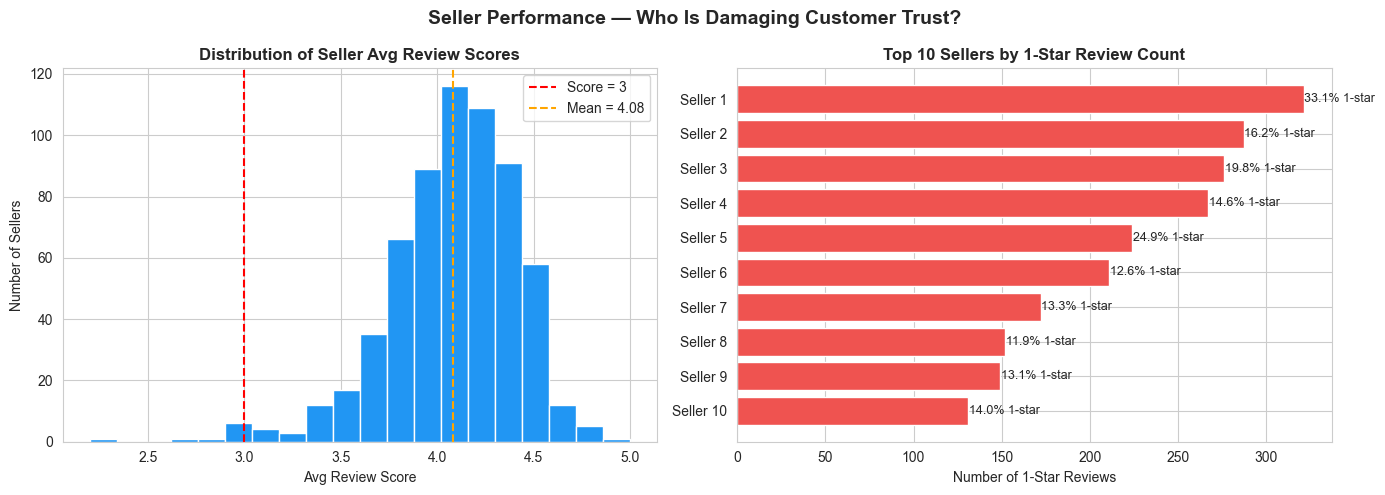

Sellers analysed (30+ orders) : 627
Sellers with avg score < 3    : 7 (1.1%)
Orders handled by bad sellers : 0.8%

Worst seller 1-star count     : 321
Worst seller avg score        : 3.34


In [9]:
# Finding 8: Seller performance — who is driving bad reviews
seller_stats = (
    master.dropna(subset=['seller_id', 'review_score'])
    .groupby('seller_id')
    .agg(
        avg_score    = ('review_score',  'mean'),
        total_orders = ('order_id',      'nunique'),
        one_stars    = ('review_score',  lambda x: (x == 1).sum())
    )
    .reset_index()
)

# Only sellers with 30+ orders (statistically meaningful)
seller_stats = seller_stats[seller_stats['total_orders'] >= 30]
seller_stats['pct_one_star'] = (
    seller_stats['one_stars'] / seller_stats['total_orders'] * 100
)

# Bad sellers: avg score below 3
bad_sellers = seller_stats[seller_stats['avg_score'] < 3]
bad_pct = len(bad_sellers) / len(seller_stats) * 100
bad_order_pct = bad_sellers['total_orders'].sum() / seller_stats['total_orders'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution across sellers
axes[0].hist(seller_stats['avg_score'], bins=20,
             color='#2196F3', edgecolor='white')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Score = 3')
axes[0].axvline(x=seller_stats['avg_score'].mean(),
                color='orange', linestyle='--', linewidth=1.5,
                label=f"Mean = {seller_stats['avg_score'].mean():.2f}")
axes[0].set_title('Distribution of Seller Avg Review Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Review Score')
axes[0].set_ylabel('Number of Sellers')
axes[0].legend()

# Top 10 worst sellers by 1-star count
worst = seller_stats.nlargest(10, 'one_stars').reset_index(drop=True)
worst['seller_short'] = ['Seller ' + str(i+1) for i in range(len(worst))]
axes[1].barh(worst['seller_short'][::-1], worst['one_stars'][::-1],
             color='#EF5350', edgecolor='white')
for bar, pct in zip(axes[1].patches, worst['pct_one_star'][::-1]):
    axes[1].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}% 1-star', va='center', fontsize=9)
axes[1].set_title('Top 10 Sellers by 1-Star Review Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of 1-Star Reviews')

plt.suptitle('Seller Performance — Who Is Damaging Customer Trust?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('finding8_seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sellers analysed (30+ orders) : {len(seller_stats):,}")
print(f"Sellers with avg score < 3    : {len(bad_sellers):,} ({bad_pct:.1f}%)")
print(f"Orders handled by bad sellers : {bad_order_pct:.1f}%")
print(f"\nWorst seller 1-star count     : {worst['one_stars'].max():.0f}")
print(f"Worst seller avg score        : {worst['avg_score'].min():.2f}")

In [10]:
print("=" * 55)
print("        EDA COMPLETE — 8 BUSINESS FINDINGS")
print("=" * 55)
print("""
SALES
  F1. Peak revenue R$1.6M in Nov 2017 — Black Friday spike
      (55% above previous month)

  F2. São Paulo = 42.7% of all revenue
      Top 3 states (SP, RJ, MG) = 71.2% combined

  F3. Revenue spread across 74 categories
      Top category (bed & bath) = only 8.4% of revenue

DELIVERY & OPERATIONS
  F4. Delivery time ranges from 8.3 days (SP)
      to 23.3 days (PA) — a 3x gap

  F5. Late orders score 2.55/5 vs 4.21/5 on-time
      → 1.67 star drop from late delivery

CUSTOMER BEHAVIOUR
  F6. Peak buying: Monday at 4PM
      Weekdays = 76% of all orders

  F7. Credit card = 75.8% of payments
      Avg 3.7 installments per order

SELLER PERFORMANCE
  F8. 7 sellers (1.1%) scoring below 3.0 avg
      One seller alone has 321 one-star reviews
""")
print("=" * 55)
print("Charts saved → finding1 through finding8 PNG files")

        EDA COMPLETE — 8 BUSINESS FINDINGS

SALES
  F1. Peak revenue R$1.6M in Nov 2017 — Black Friday spike
      (55% above previous month)

  F2. São Paulo = 42.7% of all revenue
      Top 3 states (SP, RJ, MG) = 71.2% combined

  F3. Revenue spread across 74 categories
      Top category (bed & bath) = only 8.4% of revenue

DELIVERY & OPERATIONS
  F4. Delivery time ranges from 8.3 days (SP)
      to 23.3 days (PA) — a 3x gap

  F5. Late orders score 2.55/5 vs 4.21/5 on-time
      → 1.67 star drop from late delivery

CUSTOMER BEHAVIOUR
  F6. Peak buying: Monday at 4PM
      Weekdays = 76% of all orders

  F7. Credit card = 75.8% of payments
      Avg 3.7 installments per order

SELLER PERFORMANCE
  F8. 7 sellers (1.1%) scoring below 3.0 avg
      One seller alone has 321 one-star reviews

Charts saved → finding1 through finding8 PNG files
